# Proyecto 2 - Modelo predictivo Saber 11 Atlántico

**Estudiante:** Maria Paula Ospina (202123208)  
**Rol:** Ciencia de datos y Despliegue
**Usuario final:** Secretaría de Educación del Atlántico  

## Pregunta de negocio

**¿En qué medida las condiciones socioeconómicas, el acceso a recursos tecnológicos en el hogar y ciertas características institucionales permiten predecir el puntaje global de los estudiantes del departamento del Atlántico en las pruebas Saber 11?**

Este notebook desarrolla un modelo basado en redes neuronales para predecir el puntaje global de los estudiantes del Atlántico

## Transformación y Limpieza según la pregunta planteada

In [1]:
#Cargar csv limpio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("../Tarea 2 - Limpieza_Datos/saber11_limpio.csv")

print(data.shape)
data.head()


(210695, 117)


,periodo,estu_tipodocumento,estu_consecutivo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,cole_depto_ubicacion,cole_mcpio_ubicacion,...,fami_cuartoshogar_dos,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion
0,20194,CC,SB11201940603865,3.080010e+11,308001008441,8,8001,107227.0,ATLANTICO,BARRANQUILLA,...,1,0,0,0,1,0,0,0,1,0
1,20194,CC,SB11201940603865,3.080010e+11,308001008441,8,8001,107227.0,ATLANTICO,BARRANQUILLA,...,1,0,0,0,1,0,0,0,1,0
2,20142,TI,SB11201420562024,1.086380e+11,108638000982,8,8638,116822.0,ATLANTICO,SABANALARGA,...,1,0,0,0,1,0,0,0,1,0
3,20162,TI,SB11201620074389,1.087580e+11,108758000066,8,8758,110072.0,ATLANTICO,SOLEDAD,...,0,0,1,0,1,0,0,0,1,0
4,20142,TI,SB11201420200133,1.080010e+11,108001003114,8,8001,82636.0,ATLANTICO,BARRANQUILLA,...,1,0,0,0,1,0,0,0,1,0


In [2]:
data.columns.tolist()

['periodo',
 'estu_tipodocumento',
 'estu_consecutivo',
 'cole_cod_dane_establecimiento',
 'cole_cod_dane_sede',
 'cole_cod_depto_ubicacion',
 'cole_cod_mcpio_ubicacion',
 'cole_codigo_icfes',
 'cole_depto_ubicacion',
 'cole_mcpio_ubicacion',
 'cole_nombre_establecimiento',
 'cole_nombre_sede',
 'cole_sede_principal',
 'estu_cod_depto_presentacion',
 'estu_cod_mcpio_presentacion',
 'estu_cod_reside_depto',
 'estu_cod_reside_mcpio',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_estadoinvestigacion',
 'estu_estudiante',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'estu_pais_reside',
 'estu_privado_libertad',
 'fami_cuartoshogar',
 'fami_educacionmadre',
 'fami_educacionpadre',
 'fami_estratovivienda',
 'fami_personashogar',
 'fami_tieneautomovil',
 'fami_tienecomputador',
 'fami_tieneinternet',
 'fami_tienelavadora',
 'desemp_ingles',
 'punt_ingles',
 'punt_matematicas',
 'punt_sociales_ciudadanas',
 'punt_c

In [3]:
data.describe()

,periodo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,...,fami_cuartoshogar_dos,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion
count,210695.000000,2.106950e+05,2.106950e+05,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.0,210695.000000,...,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000
mean,20182.860082,1.765473e+11,1.764552e+11,8.041268,8310.522101,226645.874335,8.057467,8279.884701,8.0,8267.028971,...,0.358229,0.026156,0.409435,0.043627,0.781134,0.192069,0.026797,0.211552,0.763212,0.025236
std,28.660215,9.495093e+10,9.492038e+10,1.474381,1504.079579,263355.385177,1.577531,1606.091500,0.0,326.811915,...,0.479481,0.159600,0.491731,0.204264,0.413479,0.393928,0.161490,0.408410,0.425112,0.156840
min,20142.000000,1.050010e+11,1.050010e+11,5.000000,5001.000000,2956.000000,5.000000,5001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20162.000000,1.080010e+11,1.080010e+11,8.000000,8001.000000,47068.000000,8.000000,8001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,20181.000000,1.086380e+11,1.086380e+11,8.000000,8001.000000,104471.000000,8.000000,8001.000000,8.0,8001.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,20194.000000,3.080010e+11,3.080010e+11,8.000000,8638.000000,211565.000000,8.000000,8638.000000,8.0,8638.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,20224.000000,4.251750e+11,4.251750e+11,85.000000,85001.000000,806489.000000,95.000000,95025.000000,8.0,8849.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Algunas variables numéricas corresponden a códigos administrativos o identificadores de colegios, sedes o municipios. Aunque aparecen como variables numéricas en el resumen descriptivo, no representan magnitudes continuas y no serán utilizadas directamente como predictores del modelo. Su uso podría introducir relaciones artificiales o poco interpretables.

#Eliminación columnas de codigos

In [4]:
columnas_eliminar = [
    # Identificadores del estudiante
    "estu_tipodocumento",
    "estu_consecutivo",
    "estu_estudiante",

    # Identificadores/códigos del colegio o sede
    "cole_cod_dane_establecimiento",
    "cole_cod_dane_sede",
    "cole_codigo_icfes",
    "cole_nombre_establecimiento",
    "cole_nombre_sede",

    # Códigos administrativos de ubicación
    "cole_cod_depto_ubicacion",
    "cole_cod_mcpio_ubicacion",
    "estu_cod_depto_presentacion",
    "estu_cod_mcpio_presentacion",
    "estu_cod_reside_depto",
    "estu_cod_reside_mcpio"
]

df = data.drop(columns=columnas_eliminar)

Se van a eliminar los puntajes especificos de cada area, dado que hacen parte del resultado de puntaje global

In [5]:
columnas_eliminar = [
    "punt_ingles",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_lectura_critica",
    "desemp_ingles"
]

df = df.drop(columns=columnas_eliminar)

In [6]:
df.columns.tolist()

['periodo',
 'cole_depto_ubicacion',
 'cole_mcpio_ubicacion',
 'cole_sede_principal',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_estadoinvestigacion',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'estu_pais_reside',
 'estu_privado_libertad',
 'fami_cuartoshogar',
 'fami_educacionmadre',
 'fami_educacionpadre',
 'fami_estratovivienda',
 'fami_personashogar',
 'fami_tieneautomovil',
 'fami_tienecomputador',
 'fami_tieneinternet',
 'fami_tienelavadora',
 'punt_global',
 'cole_naturaleza_no oficial',
 'cole_naturaleza_oficial',
 'cole_bilingue_n',
 'cole_bilingue_s',
 'cole_jornada_completa',
 'cole_jornada_mañana',
 'cole_jornada_noche',
 'cole_jornada_sabatina',
 'cole_jornada_tarde',
 'cole_jornada_unica',
 'cole_calendario_a',
 'cole_calendario_b',
 'cole_calendario_otro',
 'cole_area_ubicacion_rural',
 'cole_area_ubicacion_urbano',
 'cole_caracter_académico',
 'cole_caracter_no aplica',
 'cole_caracter_

In [7]:
#Decidir qué variables se van a usar para el modelo
cols_fami = [c for c in df.columns if c.startswith("fami_")]
cols_cole = [c for c in df.columns if c.startswith("cole_")]
cols_estu = [c for c in df.columns if c.startswith("estu_")]

print("Variables familiares:", len(cols_fami))
print("Variables institucionales:", len(cols_cole))
print("Variables estudiante:", len(cols_estu))

Variables familiares: 60
Variables institucionales: 25
Variables estudiante: 10


In [8]:
cols_object = df.select_dtypes(include="object").columns.tolist()
cols_object

['cole_depto_ubicacion',
 'cole_mcpio_ubicacion',
 'cole_sede_principal',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_estadoinvestigacion',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'estu_pais_reside',
 'estu_privado_libertad',
 'fami_cuartoshogar',
 'fami_educacionmadre',
 'fami_educacionpadre',
 'fami_personashogar',
 'fami_tieneautomovil',
 'fami_tienecomputador',
 'fami_tieneinternet',
 'fami_tienelavadora']

In [9]:
cols_object = [
    'cole_depto_ubicacion',
    'cole_mcpio_ubicacion',
    'cole_sede_principal',
    'estu_depto_presentacion',
    'estu_depto_reside',
    'estu_estadoinvestigacion',
    'estu_fechanacimiento',
    'estu_genero',
    'estu_mcpio_presentacion',
    'estu_mcpio_reside',
    'estu_nacionalidad',
    'estu_pais_reside',
    'estu_privado_libertad',
    'fami_tienecomputador',
    'fami_tieneinternet'
]

for c in cols_object:
    print("\n" + "="*80)
    print(c)
    print("Número de categorías:", df[c].nunique(dropna=False))
    print(df[c].value_counts(dropna=False).head(20))


cole_depto_ubicacion
Número de categorías: 19
cole_depto_ubicacion
ATLANTICO          210373
SANTANDER             102
BOLIVAR                52
BOGOTA                 41
BOGOTÁ                 38
MAGDALENA              20
ANTIOQUIA              17
CUNDINAMARCA           15
BOYACA                  9
VALLE                   7
CORDOBA                 7
CESAR                   4
LA GUAJIRA              3
META                    2
CASANARE                1
CHOCO                   1
RISARALDA               1
NORTE SANTANDER         1
CAQUETA                 1
Name: count, dtype: int64

cole_mcpio_ubicacion
Número de categorías: 71
cole_mcpio_ubicacion
BARRANQUILLA        115675
SOLEDAD              39052
SABANALARGA           8584
PUERTO COLOMBIA       7909
MALAMBO               6742
BARANOA               5594
GALAPA                3155
PALMAR DE VARELA      2834
SABANAGRANDE          2578
LURUACO               1955
PONEDERA              1839
JUAN DE ACOSTA        1508
POLONUEVO           

Se va a eliminar cole_depto_ubicacion, estu_depto_presentacion y estu_depto_reside porque casi todos los registros corresponden al departamento del Atlántico, por lo que la variable presenta muy baja variabilidad y aporta poca información predictiva.

In [10]:
df = df.drop(columns=["estu_depto_presentacion"], errors="ignore")
df = df.drop(columns=["cole_depto_ubicacion"], errors="ignore")
df = df.drop(columns=["estu_depto_reside"], errors="ignore")

Se va a eliminar estu_estadoinvestigacion porque casi todos los registros están en publicar, y esto representa un estado administrativo del registro, por contexto del negocio y objetivo del final se cree que no representa información relevante

In [11]:
df = df.drop(columns=["estu_estadoinvestigacion"], errors="ignore")

Ahora, se decidió usar la columna fecha_nacimiento para calcular la edad en la que fue presentada la prueba, se considera que puede ser una feature importante para encontrar el puntaje global

In [12]:
import pandas as pd
import numpy as np

# Convertir fecha de nacimiento a datetime
df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"],
    errors="coerce",
    dayfirst=True
)

# Extraer año de nacimiento
df["anio_nacimiento"] = df["estu_fechanacimiento"].dt.year

# Extraer año de presentación desde periodo
df["anio_presentacion"] = (df["periodo"] // 10).astype(int)

# Calcular edad aproximada al momento de presentar la prueba
df["edad_presentacion"] = (
    df["anio_presentacion"] - df["anio_nacimiento"]
)

# Revisar resultado
df["edad_presentacion"].describe()

count    210627.000000
mean         17.392015
std           2.943205
min           0.000000
25%          16.000000
50%          17.000000
75%          18.000000
max         122.000000
Name: edad_presentacion, dtype: float64

In [13]:
#Calcular porcentaje de edades inválidas
# Definir criterio de edad válida
edad_min = 13
edad_max = 60

# Identificar edades inválidas
mask_edad_invalida = (
    (df["edad_presentacion"] < edad_min) |
    (df["edad_presentacion"] > edad_max) |
    (df["edad_presentacion"].isna())
)

n_invalidas = mask_edad_invalida.sum()
pct_invalidas = n_invalidas / len(df) * 100

print("Total de registros:", len(df))
print("Número de edades inválidas o faltantes:", n_invalidas)
print("Porcentaje de edades inválidas o faltantes:", round(pct_invalidas, 4), "%")

Total de registros: 210695
Número de edades inválidas o faltantes: 398
Porcentaje de edades inválidas o faltantes: 0.1889 %


In [14]:
#Se imputa la mediana de edad para los casos inválidos o faltantes dado que es el 0.18%
# Crear indicador de edad inválida original
df["edad_invalida_original"] = mask_edad_invalida.astype(int)

# Mediana de edades válidas
mediana_edad = df.loc[
    ~mask_edad_invalida,
    "edad_presentacion"
].median()

# Imputar edades inválidas con la mediana
df.loc[mask_edad_invalida, "edad_presentacion"] = mediana_edad

print("Mediana usada:", mediana_edad)
print(df["edad_presentacion"].describe())

Mediana usada: 17.0
count    210695.000000
mean         17.373426
std           2.377505
min          13.000000
25%          16.000000
50%          17.000000
75%          18.000000
max          60.000000
Name: edad_presentacion, dtype: float64


In [15]:
df = df.drop(
    columns=[
        "estu_fechanacimiento",
        "anio_nacimiento",
        "anio_presentacion"
    ],
    errors="ignore"
)

La variable estu_fechanacimiento fue transformada en edad_presentacion, calculada como la diferencia entre el año de presentación de la prueba y el año de nacimiento del estudiante. Durante la validación se identificaron edades no plausibles para el contexto de Saber 11, como valores menores a 13 años o mayores a 60 años. Estos casos representaban únicamente el 0,1889% de la base, por lo que se decidió imputarlos con la mediana de las edades válidas, equivalente a 17 años, y crear una variable indicadora para señalar los registros con edad originalmente inválida o faltante.

Antes del tratamiento, edad_presentacion tenía valores entre 0 y 122 años, una media de 17,39 y una desviación estándar de 2,94. Después de la imputación, la variable quedó en un rango de 13 a 60 años, con media de 17,37, mediana de 17 y desviación estándar de 2,38. La mediana se mantuvo estable, mientras que la reducción de la desviación estándar evidencia que se corrigieron valores extremos no plausibles sin alterar de forma significativa la distribución central de la variable.

Además, se decidió eliminar estu_privado_libertad dado que estaba extremadamente desbalanceada con solo 45 casos de "SI" y  210650 de "NO"

In [16]:
df = df.drop(columns=["estu_privado_libertad"], errors="ignore")

También, se decidió eliminar estu_pais_reside dado que los datos son muy similares a los de la columna estu_nacionalidad

In [17]:
df = df.drop(columns=["estu_pais_reside"], errors="ignore")

In [18]:
cols_object = df.select_dtypes(include="object").columns.tolist()
cols_object

['cole_mcpio_ubicacion',
 'cole_sede_principal',
 'estu_genero',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'fami_cuartoshogar',
 'fami_educacionmadre',
 'fami_educacionpadre',
 'fami_personashogar',
 'fami_tieneautomovil',
 'fami_tienecomputador',
 'fami_tieneinternet',
 'fami_tienelavadora']

In [19]:

for c in cols_object:
    print("\n" + "="*80)
    print(c)
    print("Número de categorías:", df[c].nunique(dropna=False))
    print(df[c].value_counts(dropna=False).head(20))


cole_mcpio_ubicacion
Número de categorías: 71
cole_mcpio_ubicacion
BARRANQUILLA        115675
SOLEDAD              39052
SABANALARGA           8584
PUERTO COLOMBIA       7909
MALAMBO               6742
BARANOA               5594
GALAPA                3155
PALMAR DE VARELA      2834
SABANAGRANDE          2578
LURUACO               1955
PONEDERA              1839
JUAN DE ACOSTA        1508
POLONUEVO             1286
CAMPO DE LA CRUZ      1208
REPELON               1115
REPELÓN                998
SANTO TOMÁS            954
SUAN                   952
SANTO TOMAS            944
CANDELARIA             918
Name: count, dtype: int64

cole_sede_principal
Número de categorías: 2
cole_sede_principal
S    205710
N      4985
Name: count, dtype: int64

estu_genero
Número de categorías: 3
estu_genero
F      111832
M       98726
NaN       137
Name: count, dtype: int64

estu_mcpio_presentacion
Número de categorías: 56
estu_mcpio_presentacion
BARRANQUILLA           128765
SOLEDAD                 34710


### Completitud

Es una dimensión en donde se mide el grado en el que un dataset contiene toda la información esperada, es decir que no tiene valores faltantes u omitidos.

In [20]:
((df.isnull().sum()/df.shape[0])).sort_values(ascending=False)

fami_estratovivienda                  0.057334
fami_tieneinternet                    0.036892
fami_tienecomputador                  0.025340
estu_genero                           0.000650
cole_sede_principal                   0.000000
                                        ...   
fami_tienelavadora_no                 0.000000
fami_tienelavadora_si                 0.000000
fami_tienelavadora_sin_informacion    0.000000
edad_presentacion                     0.000000
edad_invalida_original                0.000000
Length: 92, dtype: float64

Las variables fami_tienecomputador y fami_tieneinternet se conservaron por representar condiciones socioeconómicas relevantes asociadas al acceso a recursos tecnológicos en el hogar. Estas variables presentaban valores faltantes equivalentes aproximadamente al 2,53% y 3,69% de los registros, respectivamente. Dado que la proporción de faltantes era baja y que el conjunto de datos ya incluía categorías explícitas de sin_informacion en otras variables familiares, se decidió tratar los valores faltantes como una categoría adicional. Posteriormente, ambas variables fueron transformadas mediante codificación dummy para ser usadas en el modelo de red neuronal.

In [21]:
# El nuevo limpieza ya genera dummies de fami_tienecomputador y fami_tieneinternet.
# Si las columnas originales siguen presentes (object), las encodeamos aquí.
# Si ya vienen como dummies (fami_tienecomputador_si, etc.), no hacemos nada.

cols_recursos = ["fami_tienecomputador", "fami_tieneinternet"]
cols_recursos_presentes = [c for c in cols_recursos if c in df.columns
                           and df[c].dtype == object]

if cols_recursos_presentes:
    for c in cols_recursos_presentes:
        df[c] = (
            df[c]
            .astype("object")
            .where(df[c].notna(), "sin_informacion")
            .astype(str)
            .str.strip()
            .str.lower()
        )
    df = pd.get_dummies(df, columns=cols_recursos_presentes, drop_first=False)
else:
    print("fami_tienecomputador/internet ya vienen como dummies, OK.")


Se descubrió que había valores faltantes para estu_genero asi que se creo la variable "sin información"

In [22]:
df["estu_genero"].value_counts(dropna=False)

estu_genero
F      111832
M       98726
NaN       137
Name: count, dtype: int64

In [23]:
if "estu_genero" in df.columns and df["estu_genero"].dtype == object:
    df["estu_genero"] = (
        df["estu_genero"]
        .astype("object")
        .where(df["estu_genero"].notna(), "sin_informacion")
        .astype(str)
        .str.strip()
        .str.lower()
    )
    df = pd.get_dummies(df, columns=["estu_genero"], drop_first=False)
    cols_genero = [c for c in df.columns if c.startswith("estu_genero_")]
    df[cols_genero] = df[cols_genero].astype(int)
else:
    print("estu_genero ya procesada o no existe, OK.")


### Validez


Esta dimensión considera la exactitud y veracidad de la información, asegurando que los datos midan lo que se supone que deben medir y que sean correctos y coherentes. Es decir, que el valor que se tiene está dentro de los valores posibles.

In [24]:
#Revisemos a nivel de los datos numéricos
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df.describe()

,periodo,fami_estratovivienda,punt_global,cole_naturaleza_no oficial,cole_naturaleza_oficial,cole_bilingue_n,cole_bilingue_s,cole_jornada_completa,cole_jornada_mañana,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_a,cole_calendario_b,cole_calendario_otro,cole_area_ubicacion_rural,cole_area_ubicacion_urbano,cole_caracter_académico,cole_caracter_no aplica,cole_caracter_técnico,cole_caracter_técnico/académico,cole_genero_femenino,cole_genero_masculino,cole_genero_mixto,fami_estratovivienda_estrato 1,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin_informacion,fami_educacionmadre_educacion profesional completa,fami_educacionmadre_educacion profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) completa,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_tecnica o tecnologica completa,fami_educacionmadre_tecnica o tecnologica incompleta,fami_educacionpadre_educacion profesional completa,fami_educacionpadre_educacion profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) completa,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_tecnica o tecnologica completa,fami_educacionpadre_tecnica o tecnologica incompleta,fami_personashogar_1 a 2,fami_personashogar_3 a 4,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o mas,fami_personashogar_sin_informacion,fami_cuartoshogar_cinco_o_mas,fami_cuartoshogar_cuatro,fami_cuartoshogar_dos,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_tres,fami_cuartoshogar_uno,fami_tieneautomovil_no,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_si,fami_tienelavadora_sin_informacion,edad_presentacion,edad_invalida_original,estu_genero_f,estu_genero_m,estu_genero_sin_informacion
count,210695.000000,198615.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000
mean,20182.860082,1.938993,249.635990,0.288284,0.711716,0.982899,0.017101,0.137692,0.386350,0.093695,0.006374,0.134365,0.241524,0.980602,0.019308,0.000090,0.029498,0.970502,0.534023,0.009715,0.215715,0.240547,0.080619,0.002240,0.917141,0.423209,0.284615,0.151855,0.050561,0.016982,0.015444,0.057334,0.135319,0.028558,0.014837,0.000921,0.023612,0.022416,0.068374,0.074055,0.289921,0.152163,0.036750,0.115072,0.038003,0.125456,0.025734,0.024130

Eliminar una columna de las categorias en forma dummie

In [25]:
# --- Eliminar columnas originales categóricas que el nuevo limpieza conserva ---
# El nuevo saber11_limpio.csv mantiene las columnas fami_ originales (object/category)
# junto con sus dummies. Si quedan en df rompen el modelo: hay que sacarlas.
cols_originales_fami = [
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_personashogar",
    "fami_cuartoshogar",
    "fami_tieneautomovil",
    "fami_tienelavadora",
]
df = df.drop(columns=cols_originales_fami, errors="ignore")

# --- drop_first manual: eliminar una dummy de referencia por grupo ---
# Nombres actualizados según normalización del nuevo limpieza
# (quitar_tildes → 'tecnica o tecnologica', 'sin_informacion' en lugar de nulos)
cols_drop_first = [
    # Colegio (nombres no cambian, el limpieza original los generó)
    "cole_naturaleza_oficial",
    "cole_bilingue_n",
    "cole_jornada_mañana",
    "cole_calendario_a",
    "cole_area_ubicacion_urbano",
    "cole_caracter_académico",
    "cole_genero_mixto",

    # Estrato — referencia: estrato 1
    "fami_estratovivienda_estrato 1",

    # Educación madre — referencia: secundaria completa
    # NUEVO: sin tildes por normalizar_educacion + quitar_tildes
    "fami_educacionmadre_secundaria (bachillerato) completa",

    # Educación padre
    "fami_educacionpadre_secundaria (bachillerato) completa",

    # Personas hogar — referencia: 3 a 4
    "fami_personashogar_3 a 4",

    # Cuartos hogar — referencia: tres
    "fami_cuartoshogar_tres",

    # Bienes del hogar
    "fami_tieneautomovil_no",
    "fami_tienelavadora_si",

    # Género
    "estu_genero_f",
]

df = df.drop(columns=cols_drop_first, errors="ignore")

print("Columnas después de drop_first:", df.shape[1])
print("Columnas fami_ que quedaron:", [c for c in df.columns if c.startswith('fami_')])


Columnas después de drop_first: 76
Columnas fami_ que quedaron: ['fami_estratovivienda_estrato 2', 'fami_estratovivienda_estrato 3', 'fami_estratovivienda_estrato 4', 'fami_estratovivienda_estrato 5', 'fami_estratovivienda_estrato 6', 'fami_estratovivienda_sin_informacion', 'fami_educacionmadre_educacion profesional completa', 'fami_educacionmadre_educacion profesional incompleta', 'fami_educacionmadre_ninguno', 'fami_educacionmadre_no aplica', 'fami_educacionmadre_no sabe', 'fami_educacionmadre_postgrado', 'fami_educacionmadre_primaria completa', 'fami_educacionmadre_primaria incompleta', 'fami_educacionmadre_secundaria (bachillerato) incompleta', 'fami_educacionmadre_sin_informacion', 'fami_educacionmadre_tecnica o tecnologica completa', 'fami_educacionmadre_tecnica o tecnologica incompleta', 'fami_educacionpadre_educacion profesional completa', 'fami_educacionpadre_educacion profesional incompleta', 'fami_educacionpadre_ninguno', 'fami_educacionpadre_no aplica', 'fami_educacionpadre

In [26]:
df.describe()

,periodo,punt_global,cole_naturaleza_no oficial,cole_bilingue_s,cole_jornada_completa,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_b,cole_calendario_otro,cole_area_ubicacion_rural,cole_caracter_no aplica,cole_caracter_técnico,cole_caracter_técnico/académico,cole_genero_femenino,cole_genero_masculino,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin_informacion,fami_educacionmadre_educacion profesional completa,fami_educacionmadre_educacion profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_tecnica o tecnologica completa,fami_educacionmadre_tecnica o tecnologica incompleta,fami_educacionpadre_educacion profesional completa,fami_educacionpadre_educacion profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_tecnica o tecnologica completa,fami_educacionpadre_tecnica o tecnologica incompleta,fami_personashogar_1 a 2,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o mas,fami_personashogar_sin_informacion,fami_cuartoshogar_cinco_o_mas,fami_cuartoshogar_cuatro,fami_cuartoshogar_dos,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_uno,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_sin_informacion,edad_presentacion,edad_invalida_original,estu_genero_m,estu_genero_sin_informacion
count,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000,210695.000000
mean,20182.860082,249.635990,0.288284,0.017101,0.137692,0.093695,0.006374,0.134365,0.241524,0.019308,0.000090,0.029498,0.009715,0.215715,0.240547,0.080619,0.002240,0.284615,0.151855,0.050561,0.016982,0.015444,0.057334,0.135319,0.028558,0.014837,0.000921,0.023612,0.022416,0.068374,0.074055,0.152163,0.036750,0.115072,0.038003,0.125456,0.025734,0.024130,0.003768,0.048354,0.022018,0.066243,0.084890,0.150198,0.036218,0.096414,0.029213,0.040798,0.377318,0.104806,0.050201,0.025055,0.049446,0.113107,0.358229,0.026156,0.043627,0.192069,0.026797,0.211552,0.025236,17.373426,0.001889,0.468573,0.000650
std,28.660215,51.735807,0.452965,0.129646,0.344577,0.291404,0.079584,0.341045,0.428008,0.137604,0.009496,0.169197,0.098087,0.411318,0.427417,0.272250,0.047278,0.451232,0.358881,0.219100,0.129204,0.123311,0.232480,0.342065,0.166561,0.120899,0.030330,0.151838,0.148033,0.252387,0.261861,0.359180,0.188147,0.319109,0.191203,0.331236,0.158341,0.153452,0.061272,0.214514,0.146741,0.248706,0.278719,0.357266,0.186833,0.295159,0.168403,0.197823,0.484717,0.306303,0.218359,0.156293,0.216798,0.

## Análisis descriptivo

Distribución de la variable objetivo

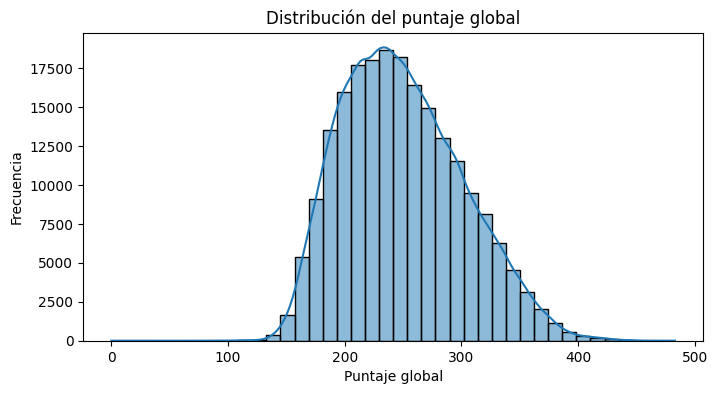

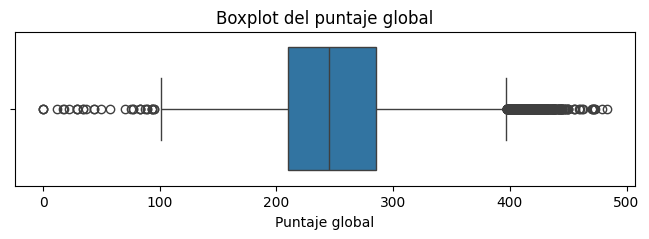

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df["punt_global"], bins=40, kde=True)
plt.title("Distribución del puntaje global")
plt.xlabel("Puntaje global")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df["punt_global"])
plt.title("Boxplot del puntaje global")
plt.xlabel("Puntaje global")
plt.show()

In [28]:
#Revisar si hay puntajes globales en 0
n_cero = (df["punt_global"] == 0).sum()
pct_cero = (df["punt_global"] == 0).mean() * 100

print("Registros con punt_global = 0:", n_cero)
print("Porcentaje:", round(pct_cero, 4), "%")

Registros con punt_global = 0: 3
Porcentaje: 0.0014 %


Como el porcentaje de valores en 0 es del 0.0014% se decide eliminarlos

In [29]:
df = df[df["punt_global"] > 0].copy()

Correlación con puntaje global

In [30]:
df.columns.tolist()

['periodo',
 'cole_mcpio_ubicacion',
 'cole_sede_principal',
 'estu_mcpio_presentacion',
 'estu_mcpio_reside',
 'estu_nacionalidad',
 'punt_global',
 'cole_naturaleza_no oficial',
 'cole_bilingue_s',
 'cole_jornada_completa',
 'cole_jornada_noche',
 'cole_jornada_sabatina',
 'cole_jornada_tarde',
 'cole_jornada_unica',
 'cole_calendario_b',
 'cole_calendario_otro',
 'cole_area_ubicacion_rural',
 'cole_caracter_no aplica',
 'cole_caracter_técnico',
 'cole_caracter_técnico/académico',
 'cole_genero_femenino',
 'cole_genero_masculino',
 'fami_estratovivienda_estrato 2',
 'fami_estratovivienda_estrato 3',
 'fami_estratovivienda_estrato 4',
 'fami_estratovivienda_estrato 5',
 'fami_estratovivienda_estrato 6',
 'fami_estratovivienda_sin_informacion',
 'fami_educacionmadre_educacion profesional completa',
 'fami_educacionmadre_educacion profesional incompleta',
 'fami_educacionmadre_ninguno',
 'fami_educacionmadre_no aplica',
 'fami_educacionmadre_no sabe',
 'fami_educacionmadre_postgrado',
 

In [31]:
score_col = "punt_global"

features = [c for c in df.columns if c != score_col]

corr = df[features + [score_col]].corr(numeric_only=True)[score_col]
corr = corr.drop(score_col).sort_values(key=abs, ascending=False)

corr.head(30)

cole_jornada_completa                                       0.349189
fami_tieneinternet_si                                       0.304775
cole_jornada_noche                                         -0.279357
fami_tienecomputador_si                                     0.279296
fami_tieneinternet_no                                      -0.270415
fami_tienecomputador_no                                    -0.265336
fami_educacionmadre_educacion profesional completa          0.250232
fami_tieneautomovil_si                                      0.246049
fami_educacionpadre_educacion profesional completa          0.238498
cole_calendario_b                                           0.227730
edad_presentacion                                          -0.211401
cole_naturaleza_no oficial                                  0.207841
cole_bilingue_s                                             0.206426
fami_educacionpadre_postgrado                               0.200812
fami_educacionmadre_postgrado     

Gráfica

C:\Users\maria\AppData\Local\Temp\ipykernel_32472\49009096.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


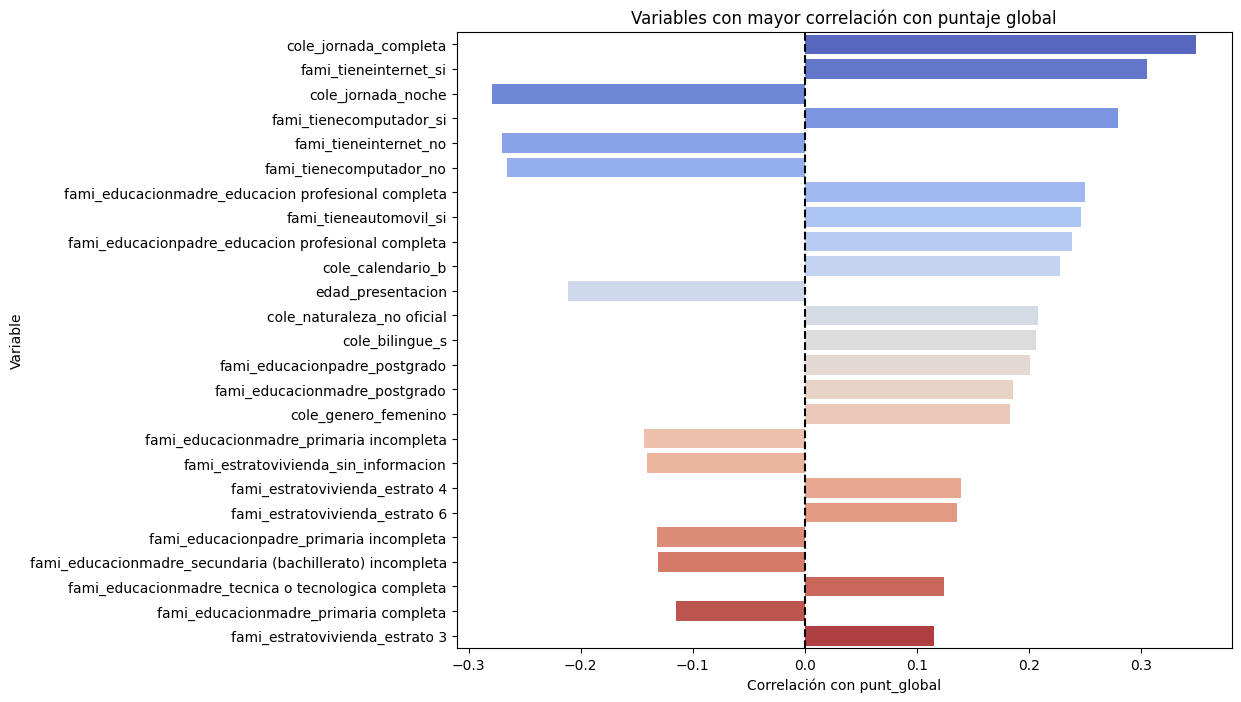

In [32]:
corr_top = corr.head(25).reset_index()
corr_top.columns = ["variable", "correlacion"]

plt.figure(figsize=(10,8))
sns.barplot(
    data=corr_top,
    x="correlacion",
    y="variable",
    palette="coolwarm"
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Variables con mayor correlación con puntaje global")
plt.xlabel("Correlación con punt_global")
plt.ylabel("Variable")
plt.show()

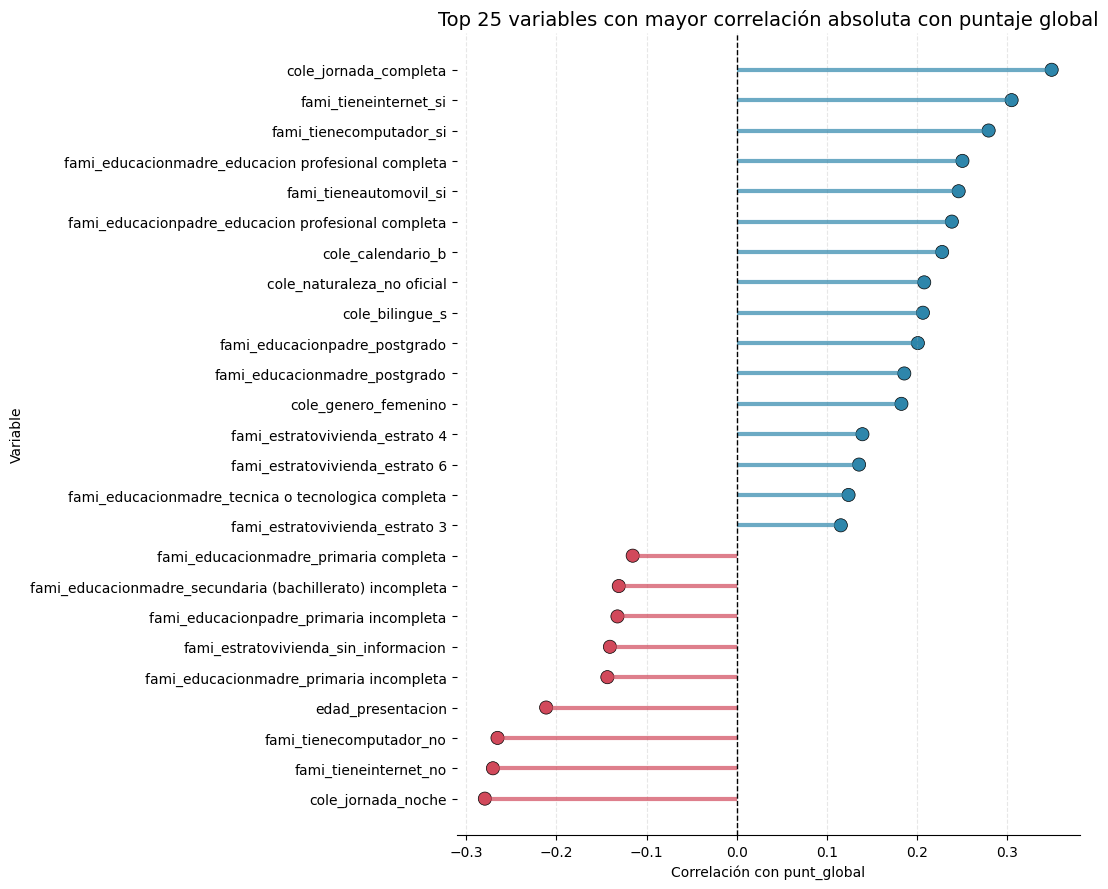

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tomar top 25 variables por correlación absoluta
corr_top = corr.reindex(corr.abs().sort_values(ascending=False).head(25).index).reset_index()
corr_top.columns = ["variable", "correlacion"]

# Ordenar para que se vea bien
corr_top = corr_top.sort_values("correlacion")

# Crear color según signo
colors = corr_top["correlacion"].apply(lambda x: "#2E86AB" if x > 0 else "#D1495B")

plt.figure(figsize=(11, 9))

# Líneas desde 0 hasta la correlación
plt.hlines(
    y=corr_top["variable"],
    xmin=0,
    xmax=corr_top["correlacion"],
    color=colors,
    alpha=0.7,
    linewidth=3
)

# Puntos finales
plt.scatter(
    corr_top["correlacion"],
    corr_top["variable"],
    color=colors,
    s=90,
    edgecolor="black",
    linewidth=0.5
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.title("Top 25 variables con mayor correlación absoluta con puntaje global", fontsize=14)
plt.xlabel("Correlación con punt_global")
plt.ylabel("Variable")

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

Variables institucionales como cole_jornada_completa, cole_jornada_noche, cole_calendario_b, cole_naturaleza_no oficial y cole_bilingue_s tienen asociaciones importantes con el puntaje global.
Variables familiares/socioeconómicas como fami_tieneinternet_si, fami_tienecomputador_si, educación profesional de madre/padre, automóvil y estrato también aparecen entre las más relacionadas.
edad_presentacion tiene correlación negativa, lo que sugiere que, en promedio, mayores edades al presentar la prueba se asocian con menor puntaje global.
Las variables fami_tieneinternet_no y fami_tienecomputador_no aparecen con correlación negativa, lo cual es coherente con que la ausencia de recursos tecnológicos se asocie con menores puntajes.

Diferencia de medias por variable dummy

In [34]:
score_col = "punt_global"

features = [c for c in df.columns if c != score_col]

relacion_dummy = []

for c in features:
    if df[c].nunique(dropna=True) == 2:
        media_0 = df.loc[df[c] == 0, score_col].mean()
        media_1 = df.loc[df[c] == 1, score_col].mean()
        n_0 = (df[c] == 0).sum()
        n_1 = (df[c] == 1).sum()

        relacion_dummy.append({
            "variable": c,
            "n_0": n_0,
            "n_1": n_1,
            "media_puntaje_0": media_0,
            "media_puntaje_1": media_1,
            "diferencia_media_1_menos_0": media_1 - media_0,
            "diferencia_abs": abs(media_1 - media_0)
        })

relacion_dummy = pd.DataFrame(relacion_dummy).sort_values(
    "diferencia_abs",
    ascending=False
)

relacion_dummy.head(30)

,variable,n_0,n_1,media_puntaje_0,media_puntaje_1,diferencia_media_1_menos_0,diferencia_abs
8,cole_calendario_b,206624,4068,247.986667,333.593412,85.606745,85.606745
2,cole_bilingue_s,207089,3603,248.231099,330.592562,82.361463,82.361463
39,fami_educacionpadre_postgrado,206053,4639,248.080945,318.868722,70.787777,70.787777
27,fami_educacionmadre_postgrado,205969,4723,248.184576,313.090409,64.905832,64.905832
20,fami_estratovivienda_estrato 6,207438,3254,248.761090,305.639828,56.878738,56.878738
3,cole_jornada_completa,181681,29011,242.421695,294.841233,52.419537,52.419537
4,cole_jornada_noche,190954,19738,254.285430,204.693231,-49.592199,49.592199
5,cole_jornada_sabatina,209349,1343,249.894984,209.821296,-40.073688,40.073688
22,fami_educacionmadre_educacion profesional comp...,182181,28511,244.518978,282.359195,37.840216,37.840216
19,fami_estratovivienda_estrato 5,207114,3578,248.999440,286.692286,37.692846,37.692846


C:\Users\maria\AppData\Local\Temp\ipykernel_32472\2604196356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


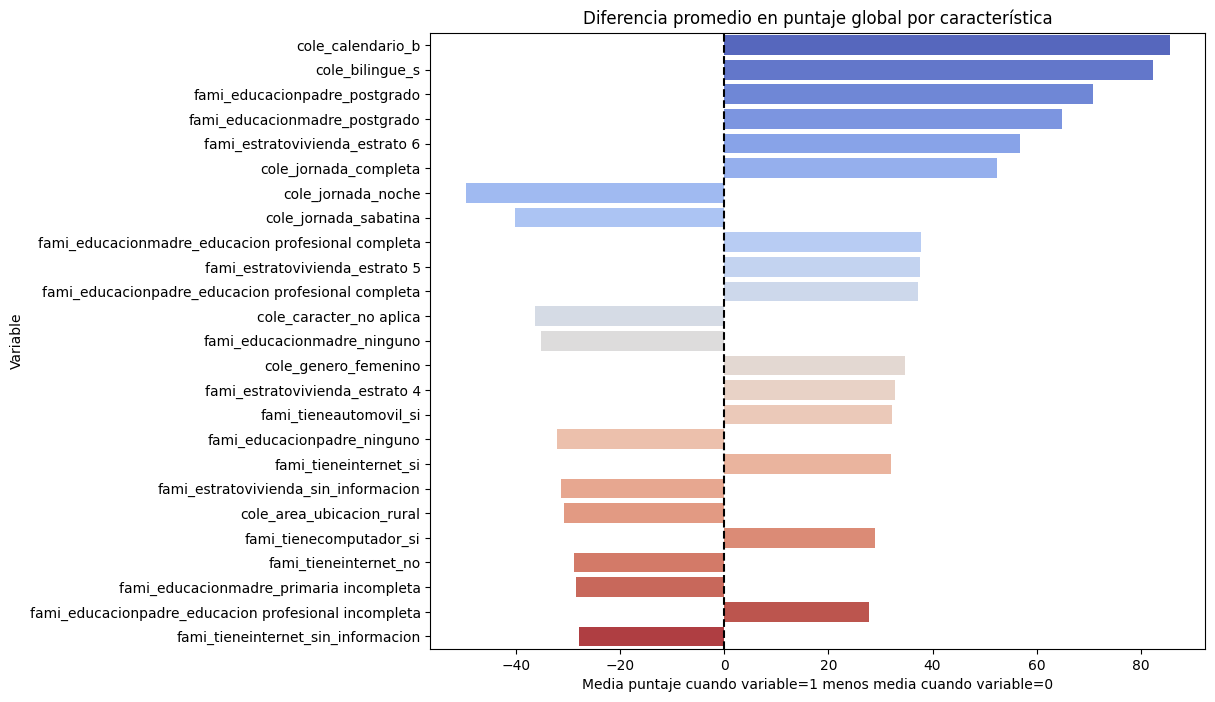

In [35]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=relacion_dummy.head(25),
    x="diferencia_media_1_menos_0",
    y="variable",
    palette="coolwarm"
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Diferencia promedio en puntaje global por característica")
plt.xlabel("Media puntaje cuando variable=1 menos media cuando variable=0")
plt.ylabel("Variable")
plt.show()

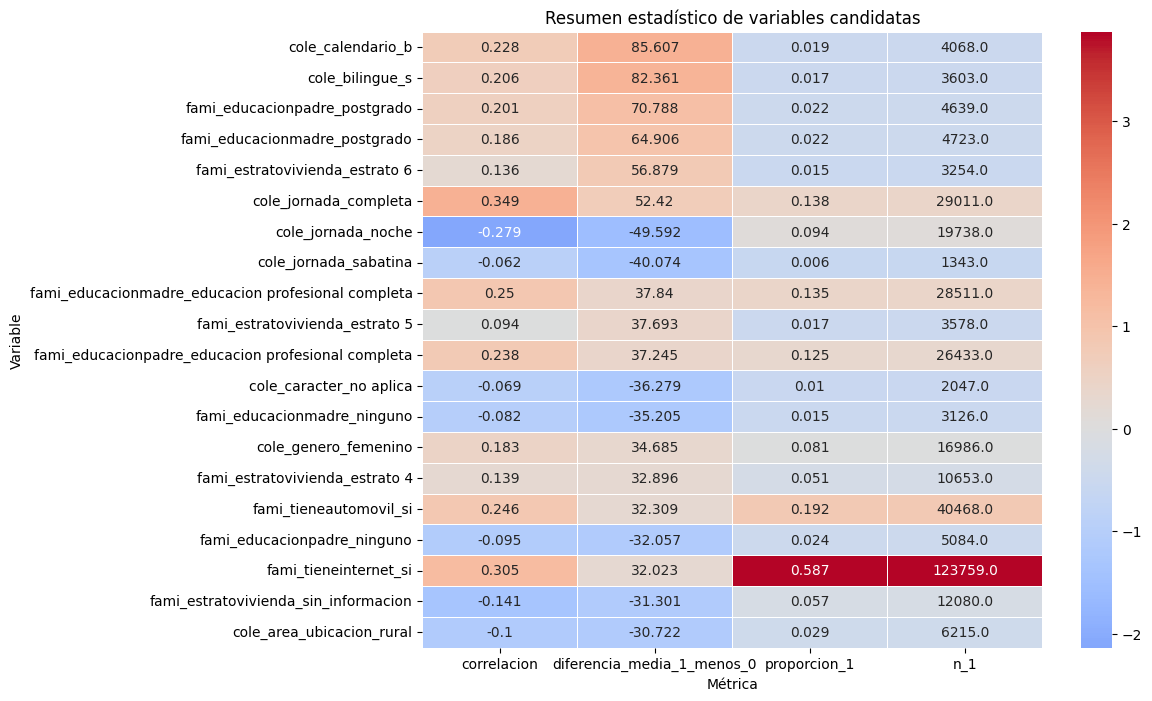

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supongo que ya tienes estas dos tablas:
# relacion_dummy
# corr

# Construir proporción de la categoría 1
resumen_vars = relacion_dummy.copy()
resumen_vars["correlacion"] = resumen_vars["variable"].map(corr)
resumen_vars["proporcion_1"] = resumen_vars["n_1"] / (resumen_vars["n_0"] + resumen_vars["n_1"])

# Quedarnos con las top 20 por diferencia absoluta
top_vars = resumen_vars.sort_values("diferencia_abs", ascending=False).head(20).copy()

# Seleccionar columnas para el heatmap
heatmap_df = top_vars[
    ["variable", "correlacion", "diferencia_media_1_menos_0", "proporcion_1", "n_1"]
].set_index("variable")

# Estandarizar solo para que las escalas sean comparables visualmente
heatmap_std = (heatmap_df - heatmap_df.mean()) / heatmap_df.std()

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_std,
    cmap="coolwarm",
    center=0,
    annot=heatmap_df.round(3),
    fmt="",
    linewidths=0.5
)
plt.title("Resumen estadístico de variables candidatas")
plt.xlabel("Métrica")
plt.ylabel("Variable")
plt.show()

## Análisis descriptivo: diferencia promedio en puntaje global por característica

Para identificar variables candidatas para el modelo de predicción del `punt_global`, se calculó la diferencia entre el puntaje promedio de los estudiantes que presentan cada característica (`variable = 1`) y el puntaje promedio de quienes no la presentan (`variable = 0`). Esta medida permite observar qué variables generan mayores diferencias descriptivas en el desempeño global.

La diferencia se interpreta así:

- Si la diferencia es **positiva**, los estudiantes con esa característica tienen, en promedio, un mayor puntaje global.
- Si la diferencia es **negativa**, los estudiantes con esa característica tienen, en promedio, un menor puntaje global.
- Mientras mayor sea la diferencia absoluta, mayor es la separación descriptiva entre los grupos.

### Variables asociadas con mayor puntaje global

Las variables con mayores diferencias positivas fueron principalmente institucionales y socioeconómicas. La característica con mayor diferencia fue `cole_calendario_b`, donde los estudiantes pertenecientes a colegios de calendario B presentan en promedio **85,61 puntos más** que los estudiantes que no pertenecen a esta categoría. Sin embargo, esta variable debe analizarse con cuidado porque solo cuenta con **4.068 registros** en la categoría positiva, lo cual representa una proporción pequeña frente al total de la base.

También se observa una diferencia alta en `cole_bilingue_s`, con una diferencia promedio de **82,36 puntos**. Esto sugiere que estudiar en un colegio bilingüe está asociado con puntajes globales más altos. Sin embargo, al igual que calendario B, esta categoría tiene una frecuencia relativamente baja, con **3.603 registros**, por lo que debe revisarse su estabilidad antes de usarla como variable principal del modelo.

En las variables familiares y socioeconómicas, destacan los niveles educativos altos de los padres. La variable `fami_educacionpadre_postgrado` presenta una diferencia promedio de **70,79 puntos**, mientras que `fami_educacionmadre_postgrado` presenta una diferencia de **64,91 puntos**. Esto indica que los estudiantes cuyos padres o madres tienen formación de posgrado tienden a obtener puntajes globales considerablemente mayores.

También aparecen variables asociadas a mayor nivel socioeconómico, como `fami_estratovivienda_estrato 6`, con una diferencia de **56,88 puntos**, y `fami_estratovivienda_estrato 5`, con **37,69 puntos**. Esto sugiere que el estrato de vivienda tiene una relación descriptiva importante con el puntaje global.

Otras variables relevantes son `cole_jornada_completa`, con una diferencia positiva de **52,42 puntos**, `fami_tieneautomovil_si`, con **32,31 puntos**, `fami_tieneinternet_si`, con **32,02 puntos**, y `fami_tienecomputador_si`, con **28,95 puntos**. Estas variables reflejan tanto condiciones institucionales como acceso a recursos del hogar.

### Variables asociadas con menor puntaje global

Algunas características presentan diferencias negativas importantes. La variable `cole_jornada_noche` muestra una diferencia de **-49,59 puntos**, lo que indica que los estudiantes de jornada nocturna tienen un puntaje global promedio considerablemente menor que los demás. De forma similar, `cole_jornada_sabatina` presenta una diferencia de **-40,07 puntos**.

La variable `fami_estratovivienda_sin estrato` tiene una diferencia de **-38,44 puntos**, lo cual sugiere que la ausencia de estrato reportado o la pertenencia a esta categoría está asociada con menores puntajes globales. También se observa una diferencia negativa en `cole_caracter_no aplica`, con **-36,28 puntos**.

En cuanto a educación de los padres, las categorías de menor nivel educativo presentan diferencias negativas. Por ejemplo, `fami_educacionmadre_ninguno` tiene una diferencia de **-35,21 puntos**, mientras que `fami_educacionpadre_ninguno` presenta una diferencia de **-32,06 puntos**. También se observan diferencias negativas en primaria incompleta de la madre y en categorías de información faltante.

Respecto al acceso a recursos tecnológicos, `fami_tieneinternet_no` tiene una diferencia de **-28,88 puntos**, mientras que `fami_tienecomputador_no` tiene una diferencia de **-27,63 puntos**. Esto refuerza la idea de que el acceso a internet y computador en el hogar está asociado con mejores resultados en Saber 11.

### Variables con categorías de baja frecuencia

Aunque algunas variables presentan diferencias muy altas, es importante considerar el número de registros en la categoría positiva. Por ejemplo, `cole_calendario_b`, `cole_bilingue_s`, `fami_educacionpadre_postgrado`, `fami_educacionmadre_postgrado` y `fami_estratovivienda_estrato 6` tienen diferencias promedio elevadas, pero sus categorías positivas representan una proporción relativamente pequeña de la base.

Por esta razón, estas variables pueden ser útiles para el modelo, pero deben revisarse junto con su frecuencia. Una diferencia alta en una categoría poco frecuente puede ser menos estable que una diferencia moderada en una categoría con muchos registros.

### Interpretación general

El análisis muestra que el puntaje global está asociado tanto con características institucionales como con condiciones familiares y socioeconómicas. En particular, las variables más relevantes descriptivamente se agrupan en cuatro dimensiones:

1. **Características institucionales del colegio**, como calendario, bilingüismo, jornada y carácter.
2. **Nivel educativo de los padres**, especialmente educación profesional y posgrado.
3. **Condiciones socioeconómicas del hogar**, como estrato, automóvil, computador e internet.
4. **Condiciones asociadas a menor desempeño**, como jornada nocturna, jornada sabatina, ausencia de internet, ausencia de computador y bajos niveles educativos de los padres.

Estos resultados sugieren que el modelo predictivo debería incluir variables de estos grupos, siempre que tengan suficiente frecuencia y estén alineadas con la pregunta de negocio.

### Variables candidatas para el modelo

A partir de este análisis descriptivo, se pueden considerar como variables candidatas iniciales:
 
- "edad_presentacion"
- "cole_jornada"
- "cole_calendario",
- "cole_bilingue",
- "cole_naturaleza",
- "fami_tieneinternet",
- "fami_tienecomputador",
- "fami_educacionmadre",
- "fami_educacionpadre",
- "fami_estratovivienda",
- "fami_tieneautomovil"

In [37]:
df.head(20)

,periodo,cole_mcpio_ubicacion,cole_sede_principal,estu_mcpio_presentacion,estu_mcpio_reside,estu_nacionalidad,punt_global,cole_naturaleza_no oficial,cole_bilingue_s,cole_jornada_completa,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_b,cole_calendario_otro,cole_area_ubicacion_rural,cole_caracter_no aplica,cole_caracter_técnico,cole_caracter_técnico/académico,cole_genero_femenino,cole_genero_masculino,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin_informacion,fami_educacionmadre_educacion profesional completa,fami_educacionmadre_educacion profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_tecnica o tecnologica completa,fami_educacionmadre_tecnica o tecnologica incompleta,fami_educacionpadre_educacion profesional completa,fami_educacionpadre_educacion profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_tecnica o tecnologica completa,fami_educacionpadre_tecnica o tecnologica incompleta,fami_personashogar_1 a 2,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o mas,fami_personashogar_sin_informacion,fami_cuartoshogar_cinco_o_mas,fami_cuartoshogar_cuatro,fami_cuartoshogar_dos,fami_cuartoshogar_sin_informacion,fami_cuartoshogar_uno,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion,fami_tienelavadora_no,fami_tienelavadora_sin_informacion,edad_presentacion,edad_invalida_original,fami_tienecomputador_no,fami_tienecomputador_si,fami_tienecomputador_sin_informacion,fami_tieneinternet_no,fami_tieneinternet_si,fami_tieneinternet_sin_informacion,estu_genero_m,estu_genero_sin_informacion
0,20194,BARRANQUILLA,S,MALAMBO,BARRANQUILLA,COLOMBIA,286.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,27.0,0,True,False,False,False,True,False,0,0
1,20194,BARRANQUILLA,S,MALAMBO,BARRANQUILLA,COLOMBIA,286.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,27.0,0,True,False,False,False,True,False,0,0
2,20142,SABANALARGA,S,SABANALARGA,SABANALARGA,COLOMBIA,223.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,16.0,0,True,False,False,True,False,False,1,0
3,20162,SOLEDAD,S,SOLEDAD,SOLEDAD,COLOMBIA,274.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17.0,0,False,True,False,False,True,False,1,0
4,20142,BARRANQUILLA,S,BARRANQUILLA,BARRANQUILLA,COLOMBIA,266.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,16.0,0,True,False,False,True,False,False,0,0
5,20142,BARRANQUILLA,S,BARRANQUILLA,BARRANQUILLA,COLOMBIA,222.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,18.0,0,False,True,False,False,True,False,0,0
6,20142,SOLEDAD,S,SOLEDAD,SOLEDAD,COLOMBIA,201.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18.0,0,False,True,False,True,False,False,1,0
7,20172,REPELON,S,SAN ESTANISLAO,REPELÓN,COLOMBIA,200.0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,16.0,0,True,F

In [38]:
drop_cols = [
    "punt_global",
    # geográficas / administrativas
    "periodo",
    "cole_mcpio_ubicacion",
    "estu_mcpio_presentacion",
    "estu_mcpio_reside",
    "estu_nacionalidad",
    # variables auxiliares
    "edad_invalida_original",
    # por si quedaron columnas originales categóricas del nuevo CSV
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_personashogar",
    "fami_cuartoshogar",
    "fami_tieneautomovil",
    "fami_tienelavadora",
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])


## Desarrollo Del Modelo

## Modelo 1

In [39]:
selected_cols = [

    "punt_global",
    "edad_presentacion",

    # jornada
    *[c for c in df.columns if c.startswith("cole_jornada")],

    # calendario
    *[c for c in df.columns if c.startswith("cole_calendario")],

    # bilingue
    *[c for c in df.columns if c.startswith("cole_bilingue")],

    # naturaleza
    *[c for c in df.columns if c.startswith("cole_naturaleza")],

    # internet
    *[c for c in df.columns if c.startswith("fami_tieneinternet")],

    # computador
    *[c for c in df.columns if c.startswith("fami_tienecomputador")],

    # educación madre
    *[c for c in df.columns if c.startswith("fami_educacionmadre")],

    # educación padre
    *[c for c in df.columns if c.startswith("fami_educacionpadre")],

    # estrato
    *[c for c in df.columns if c.startswith("fami_estratovivienda")],

    # automóvil
    *[c for c in df.columns if c.startswith("fami_tieneautomovil")]
]

df = df[selected_cols]


In [40]:
df.head()

,punt_global,edad_presentacion,cole_jornada_completa,cole_jornada_noche,cole_jornada_sabatina,cole_jornada_tarde,cole_jornada_unica,cole_calendario_b,cole_calendario_otro,cole_bilingue_s,cole_naturaleza_no oficial,fami_tieneinternet_no,fami_tieneinternet_si,fami_tieneinternet_sin_informacion,fami_tienecomputador_no,fami_tienecomputador_si,fami_tienecomputador_sin_informacion,fami_educacionmadre_educacion profesional completa,fami_educacionmadre_educacion profesional incompleta,fami_educacionmadre_ninguno,fami_educacionmadre_no aplica,fami_educacionmadre_no sabe,fami_educacionmadre_postgrado,fami_educacionmadre_primaria completa,fami_educacionmadre_primaria incompleta,fami_educacionmadre_secundaria (bachillerato) incompleta,fami_educacionmadre_sin_informacion,fami_educacionmadre_tecnica o tecnologica completa,fami_educacionmadre_tecnica o tecnologica incompleta,fami_educacionpadre_educacion profesional completa,fami_educacionpadre_educacion profesional incompleta,fami_educacionpadre_ninguno,fami_educacionpadre_no aplica,fami_educacionpadre_no sabe,fami_educacionpadre_postgrado,fami_educacionpadre_primaria completa,fami_educacionpadre_primaria incompleta,fami_educacionpadre_secundaria (bachillerato) incompleta,fami_educacionpadre_sin_informacion,fami_educacionpadre_tecnica o tecnologica completa,fami_educacionpadre_tecnica o tecnologica incompleta,fami_estratovivienda_estrato 2,fami_estratovivienda_estrato 3,fami_estratovivienda_estrato 4,fami_estratovivienda_estrato 5,fami_estratovivienda_estrato 6,fami_estratovivienda_sin_informacion,fami_tieneautomovil_si,fami_tieneautomovil_sin_informacion
0,286.0,27.0,0,0,0,0,0,0,0,0,1,False,True,False,True,False,False,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,286.0,27.0,0,0,0,0,0,0,0,0,1,False,True,False,True,False,False,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,223.0,16.0,0,0,0,0,0,0,0,0,0,True,False,False,True,False,False,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0
3,274.0,17.0,0,0,0,0,0,0,0,0,0,False,True,False,False,True,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,266.0,16.0,0,0,0,1,0,0,0,0,0,True,False,False,True,False,False,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0


In [41]:
#Para dash hay que guardar el orden de las columnas
model_columns = df.columns.tolist()
import joblib
joblib.dump(model_columns, "model_columns.pkl")

['model_columns.pkl']

In [42]:
X = df.drop(columns=["punt_global"])
y = df["punt_global"]

In [43]:
X.dtypes.value_counts()

int64      41
bool        6
float64     1
Name: count, dtype: int64

In [44]:
#Pasar todo a float para evitar problemas con el modelo
X = X.astype(float)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(168553, 48)
(42139, 48)


In [46]:
import numpy as np
from tensorflow.keras.layers import Normalization

normalizer = Normalization()

normalizer.adapt(
    np.array(X_train)
)

In [47]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

model = keras.Sequential([

    normalizer,

    layers.Dense(
        32,
        activation='relu'
    ),

    layers.Dense(1)
])

In [48]:
model.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (168553, 48)           │            97 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (392.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 97 (392.00 B)

In [49]:
early_stop = keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [50]:
history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=200,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/200
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 12787.0088 - mae: 82.1676 - val_loss: 2243.9915 - val_mae: 37.5623
Epoch 2/200
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1990.0111 - mae: 35.4150 - val_loss: 1919.5281 - val_mae: 34.9419
Epoch 3/200
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1872.1309 - mae: 34.5000 - val_loss: 1865.0463 - val_mae: 34.4661
Epoch 4/200
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1830.4614 - mae: 34.1940 - val_loss: 1833.6810 - val_mae: 34.2969
Epoch 5/200
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1804.3584 - mae: 33.9947 - val_loss: 1808.9513 - val_mae: 34.0426
Epoch 6/200
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1784.8020 - mae: 33.8197 - val_loss: 1791.1099 - val_mae: 33.9333
Epoch 7/200
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1770.3556 - mae: 33.7050 - val_loss: 1780.9380 - val_mae: 33.8683
Epoch 8/200
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1760.8251 - mae: 33.6298 - val_lo

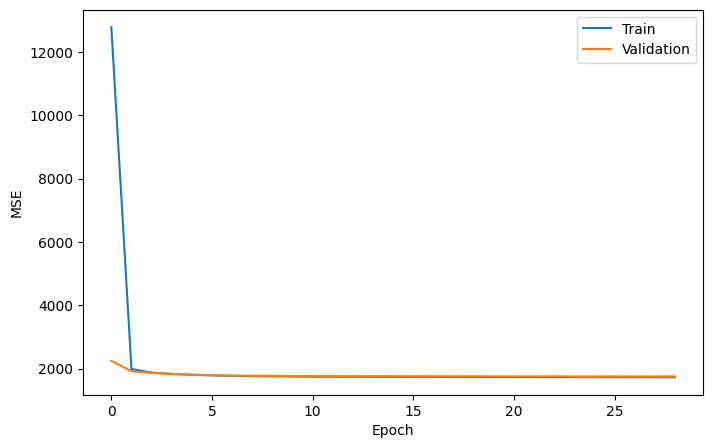

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train'
)

plt.plot(
    history.history['val_loss'],
    label='Validation'
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [52]:
pred = model.predict(X_test)

1317/1317 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step


In [53]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

mae = mean_absolute_error(
    y_test,
    pred
)
r2 = r2_score(
    y_test,
    pred
)

print("RMSE:",rmse)
print("MAE:",mae)
print("R2:",r2)

RMSE: 41.83222736745575
MAE: 33.52726629948779
R2: 0.3458179974816419


## Modelo 2 - mejora sobre el modelo 1

In [54]:
X = df.drop(columns=["punt_global"])
y = df["punt_global"]

X.dtypes.value_counts()

#Pasar todo a float para evitar problemas con el modelo
X = X.astype(float)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

import numpy as np
from tensorflow.keras.layers import Normalization

normalizer = Normalization()

normalizer.adapt(
    np.array(X_train)
)


(168553, 48)
(42139, 48)


In [55]:
import mlflow
import mlflow.keras

neurons1 = 64
neurons2 = 32
drop = 0.2

experiment = mlflow.set_experiment(
    "saber11_regresion_atlantico"
)

with mlflow.start_run():

    mlflow.keras.autolog()

    normalizer = layers.Normalization()
    normalizer.adapt(np.array(X_train))

    model2 = keras.Sequential([

        normalizer,

        layers.Dense(
            neurons1,
            activation='relu'
        ),

        layers.Dropout(drop),

        layers.Dense(
            neurons2,
            activation='relu'
        ),

        layers.Dense(1)
    ])

    model2.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history2 = model2.fit(

        X_train,
        y_train,

        validation_split=.2,

        epochs=100,

        batch_size=32,

        callbacks=[early_stop],

        verbose=1
    )

    pred2 = model2.predict(X_test).flatten()

    mse2 = mean_squared_error(y_test,pred2)
    rmse2 = np.sqrt(mse2)
    mae2 = mean_absolute_error(y_test,pred2)
    r22 = r2_score(y_test,pred2)

    mlflow.log_metric("rmse", rmse2)
    mlflow.log_metric("mae", mae2)
    mlflow.log_metric("r2", r22)

    print(rmse2, mae2, r22)

2026/05/25 12:17:31 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.


Epoch 1/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 5296.1929 - mae: 50.1049 - val_loss: 1819.4128 - val_mae: 34.1063
Epoch 2/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 2205.4280 - mae: 37.3638 - val_loss: 1788.2823 - val_mae: 33.9005
Epoch 3/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 2110.8347 - mae: 36.6216 - val_loss: 1781.4346 - val_mae: 33.7188
Epoch 4/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 2050.7009 - mae: 36.1059 - val_loss: 1819.1416 - val_mae: 33.9871
Epoch 5/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1997.8827 - mae: 35.7185 - val_loss: 1814.9700 - val_mae: 33.9313
Epoch 6/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1961.1378 - mae: 35.3518 - val_loss: 1775.4072 - val_mae: 33.7315
Epoch 7/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1934.8328 - mae: 35.1550 - val_loss: 1781.0139 - val_mae: 33.7943
Epoch 8/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1905.2664 - mae: 34.8956 - val_los

2026/05/25 12:20:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


1317/1317 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
41.78702287388875 33.545022064689135 0.3472310701312763


Este modelo no mejora significativamente frente al modelo 1. R2 casi igual, en modelo 1 fue 0.345 y en modelo 2 fue 0.347

## Modelo 3 - Sin dropout

In [56]:
X = df.drop(columns=["punt_global"])
y = df["punt_global"]

X.dtypes.value_counts()

#Pasar todo a float para evitar problemas con el modelo
X = X.astype(float)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

import numpy as np
from tensorflow.keras.layers import Normalization

normalizer = Normalization()

normalizer.adapt(
    np.array(X_train)
)


(168553, 48)
(42139, 48)


In [59]:
import numpy as np
import mlflow
import mlflow.keras

from tensorflow import keras
from keras import layers

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# MLflow server local
mlflow.set_tracking_uri(
    "file:./mlruns_modelreg"
)

# experimento
experiment = mlflow.set_experiment(
    "saber11_regresion_atlantico"
)

# numpy para MLflow
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

# hiperparámetros
neurons1 = 64
neurons2 = 32
activation = "relu"
optimizer = "adam"
epochs = 100
batch_size = 32
patience = 5

tf.keras.utils.set_random_seed(42)

with mlflow.start_run(
    experiment_id=experiment.experiment_id
):

    # autolog keras
    mlflow.keras.autolog()

    # normalización
    normalizer = layers.Normalization()
    normalizer.adapt(X_train_np)

    # modelo
    model3 = keras.Sequential([

        normalizer,

        layers.Dense(
            neurons1,
            activation=activation
        ),

        layers.Dense(
            neurons2,
            activation=activation
        ),

        layers.Dense(1)
    ])

    model3.compile(

        optimizer=optimizer,

        loss="mse",

        metrics=["mae"]
    )

    # early stopping
    early_stop = keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=patience,

        restore_best_weights=True
    )

    # entrenamiento
    history3 = model3.fit(

        X_train_np,
        y_train,

        validation_split=0.2,

        epochs=epochs,

        batch_size=batch_size,

        callbacks=[early_stop],

        verbose=1
    )

    # predicción
    pred3 = model3.predict(
        X_test_np
    ).flatten()

    # métricas
    mse3 = mean_squared_error(
        y_test,
        pred3
    )

    rmse3 = np.sqrt(mse3)

    mae3 = mean_absolute_error(
        y_test,
        pred3
    )

    r23 = r2_score(
        y_test,
        pred3
    )

    # registrar parámetros
    mlflow.log_param(
        "neurons_1",
        neurons1
    )

    mlflow.log_param(
        "neurons_2",
        neurons2
    )

    mlflow.log_param(
        "activation",
        activation
    )

    mlflow.log_param(
        "optimizer",
        optimizer
    )

    mlflow.log_param(
        "epochs",
        epochs
    )

    mlflow.log_param(
        "batch_size",
        batch_size
    )

    mlflow.log_param(
        "patience",
        patience
    )

    # registrar modelo
    mlflow.keras.log_model(
        model3,
        "keras-model"
    )

    # registrar métricas
    mlflow.log_metric(
        "mse",
        mse3
    )

    mlflow.log_metric(
        "rmse",
        rmse3
    )

    mlflow.log_metric(
        "mae",
        mae3
    )

    mlflow.log_metric(
        "r2",
        r23
    )

    print("RMSE:", rmse3)
    print("MAE:", mae3)
    print("R2:", r23)

c:\Users\maria\OneDrive - Universidad de los Andes\Universidad\Octavo Semestre\Analitica\Modelos-predictivos-Atlantico\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/25 12:29:55 INFO mlflow.tracking.fluent: Experiment with name 'saber11_regresion_atlantico' does not exist. Creating a new experiment.
2026/05/25 12:29:55 WARNING mlflow.keras.autologging: Failed to log dataset information to MLflow. Reason: 'Series' object has no attribute 'flatten'


Epoch 1/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 3984.2756 - mae: 43.1184 - val_loss: 1828.2155 - val_mae: 34.2690
Epoch 2/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1788.5258 - mae: 33.8492 - val_loss: 1803.6589 - val_mae: 34.0303
Epoch 3/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1768.9810 - mae: 33.6667 - val_loss: 1796.6893 - val_mae: 33.9550
Epoch 4/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1759.4662 - mae: 33.5758 - val_loss: 1792.5621 - val_mae: 33.9153
Epoch 5/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1753.1775 - mae: 33.5153 - val_loss: 1789.0417 - val_mae: 33.8750
Epoch 6/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1748.5597 - mae: 33.4690 - val_loss: 1787.1124 - val_mae: 33.8535
Epoch 7/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1744.9626 - mae: 33.4323 - val_loss: 1785.2478 - val_mae: 33.8361
Epoch 8/100
4214/4214 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 1741.9894 - mae: 33.4029 - val_los

2026/05/25 12:35:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


1317/1317 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step


2026/05/25 12:35:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 12:35:32 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


RMSE: 42.081289747723424
MAE: 33.73140237395834
R2: 0.33800501821422824


Este modelo presenta una leve desmejora en el r2 con respecto al modelo 2, se decide utilizar el modelo 2 como modelo final para el dash

In [62]:
# ============================================================
# GUARDAR MODELO Y COLUMNAS PARA EL DASHBOARD
# Nombres exactos que usa el dash:
#   modelo_general_regresion.h5
#   columnas_general_encoded.pkl
# ============================================================
import os
import joblib

MODELS_DIR = "..\models"  
os.makedirs(MODELS_DIR, exist_ok=True)

# Guardar modelo Keras en formato .h5
model2.save(os.path.join(MODELS_DIR, "modelo_general_regresion.h5"))
print("Modelo guardado:", os.path.join(MODELS_DIR, "modelo_general_regresion.h5"))

# Guardar las columnas en el orden exacto con que se entrenó
# X_train fue construido desde df sin punt_global, ya limpio y sin columnas extra
cols_general = list(X_train.columns) if hasattr(X_train, 'columns') else list(X.columns)
joblib.dump(cols_general, os.path.join(MODELS_DIR, "columnas_general_encoded.pkl"))
print("Columnas guardadas:", len(cols_general), "features")
print(cols_general)


Modelo guardado: ..\models\modelo_general_regresion.h5
Columnas guardadas: 48 features
['edad_presentacion', 'cole_jornada_completa', 'cole_jornada_noche', 'cole_jornada_sabatina', 'cole_jornada_tarde', 'cole_jornada_unica', 'cole_calendario_b', 'cole_calendario_otro', 'cole_bilingue_s', 'cole_naturaleza_no oficial', 'fami_tieneinternet_no', 'fami_tieneinternet_si', 'fami_tieneinternet_sin_informacion', 'fami_tienecomputador_no', 'fami_tienecomputador_si', 'fami_tienecomputador_sin_informacion', 'fami_educacionmadre_educacion profesional completa', 'fami_educacionmadre_educacion profesional incompleta', 'fami_educacionmadre_ninguno', 'fami_educacionmadre_no aplica', 'fami_educacionmadre_no sabe', 'fami_educacionmadre_postgrado', 'fami_educacionmadre_primaria completa', 'fami_educacionmadre_primaria incompleta', 'fami_educacionmadre_secundaria (bachillerato) incompleta', 'fami_educacionmadre_sin_informacion', 'fami_educacionmadre_tecnica o tecnologica completa', 'fami_educacionmadre_tec